# Movie Popularity and Audience Preference Trends

In this project, I analyze a movie dataset to explore how audience preferences and movie popularity have evolved over time.

The analysis focuses on the following: 
- How movie genres have changed over the decades
- Whether higher-budget films tend to be more popular
- How language trends have changed over the decades. 

The dataset is analyzed using Python, Pandas, and SQL queries via SQLite, with visualizations created with Matplotlib.

# 1. Importing the necessary libraries and loading in the dataset

First, the dataset is loaded using Pandas to inspect its structure and identify potential issues like missing values or irrelevant columns.

The dataset contains information about movies including genre, runtime, budget, ratings, popularity score, language and release date. These variables will be used to analyze how different factors may influence preferences and popularity.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [4]:
movies = pd.read_csv("data/movie_dataset.csv")

movies.info()
movies.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


Before performing any analysis, it is important to understand the completeness of the dataset. 

In the next step, i will check the dataset for missing values across all columns to determine which fields may require cleaning or removal

In [5]:
movies.isna().sum()

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64

Some columns in the dataset contain textual or metadata information that is not relevant for the type of analysis performed in this project. Moreover, columns like homepage, tagline and keywords contain high levels of missing data. 

To simplify the database and to focus on only the features which are useful, irrelevant columns are removed.

In [6]:
movies = movies.drop(['homepage', 'keywords', 'overview', 'status', 'tagline', 'cast', 'crew'], axis=1)

# 2. Cleaning the data 

To analyze trends over time, the release date is converted into a datetime format and a new year column is extracted.

This allows the dataset to be grouped by year or decade when analyzing changes in movie production and audience preferences.

In [7]:
release_dates = pd.to_datetime(movies['release_date'], errors='coerce')
movies['year'] = release_dates.dt.year
movies = movies.dropna(subset=['year'])
movies['year'] = movies['year'].astype(int)

Some entries contain unrealistic runtime values or missing data. Movies with runtimes of zero are filtered out to ensure the dataset represents realistic movie durations.

In [8]:
movies = movies[movies['runtime'] > 0]
movies['runtime'] = movies['runtime'].fillna(movies['runtime'].median())

In many movie datasets, a budget or revenue value of 0 typically indicates missing information rather than actual value. 

These values are replaced with missing values to prevent them from distorting later analysis.

In [9]:
movies['budget'] = movies['budget'].replace(0, pd.NA)
movies['revenue'] = movies['revenue'].replace(0, pd.NA)


# 3. Feature engineering

To make the dataset easier to analyze, several additional features are created. These derived variables allow trends to be studied more effectively and help simplify comparisons between movies. 

Since many movies belong to multiple genres, the primary genre is extracted to simplify genre-based analysis.

In [10]:
movies['main_genre'] = movies['genres'].apply(lambda x: str(x).split()[0] if pd.notnull(x) else x)

Movies are grouped into 3 budget categories (Low, Medium, High). This makes it easier to compare how different budget levels relate to popularity.

In [11]:
def budget_category(amount):
    if pd.isna(amount):
        return "Unknown"
    elif amount < 10000000:
        return "Low"
    elif amount < 50000000:
        return "Medium"
    else:
        return "High"

movies['budget_category'] = movies['budget'].apply(budget_category)

A decade feature is created to analyze long-term trends.

In [12]:
movies['decade'] = (movies['year'] //  10) * 10

The created features:

In [13]:
movies[['year','decade', 'main_genre','budget_category','popularity','vote_average']].head()

,year,decade,main_genre,budget_category,popularity,vote_average
0,2009,2000,Action,High,150.437577,7.2
1,2007,2000,Adventure,High,139.082615,6.9
2,2015,2010,Action,High,107.376788,6.3
3,2012,2010,Action,High,112.312950,7.6
4,2012,2010,Action,High,43.926995,6.1


# 4.  Storing the Dataset in SQLite
The cleaned dataset is stored in a SQLite database. This allows SQL queries to be used alongside Python to analyze the data, simulating a typical data analysis workflow.

In [14]:
conn = sqlite3.connect("movies.db3")
movies.to_sql("movies", conn, if_exists="replace", index=False)

4766

# 5. Analysing the data

### 1. How have genres shifted over recent decades?

In [15]:
query1 = """
SELECT main_genre, decade, COUNT(*) AS genre_count
FROM movies
WHERE decade IN (1990, 2000, 2010)
GROUP BY decade, main_genre
ORDER BY decade, genre_count DESC;
"""

genres_trends = pd.read_sql_query(query1, conn)

Since the number of movies varies significantly across decades, raw counts can be misleading.
To account for this, genre counts are normalized within each decade to show the proportion of movies belonging to each genre.

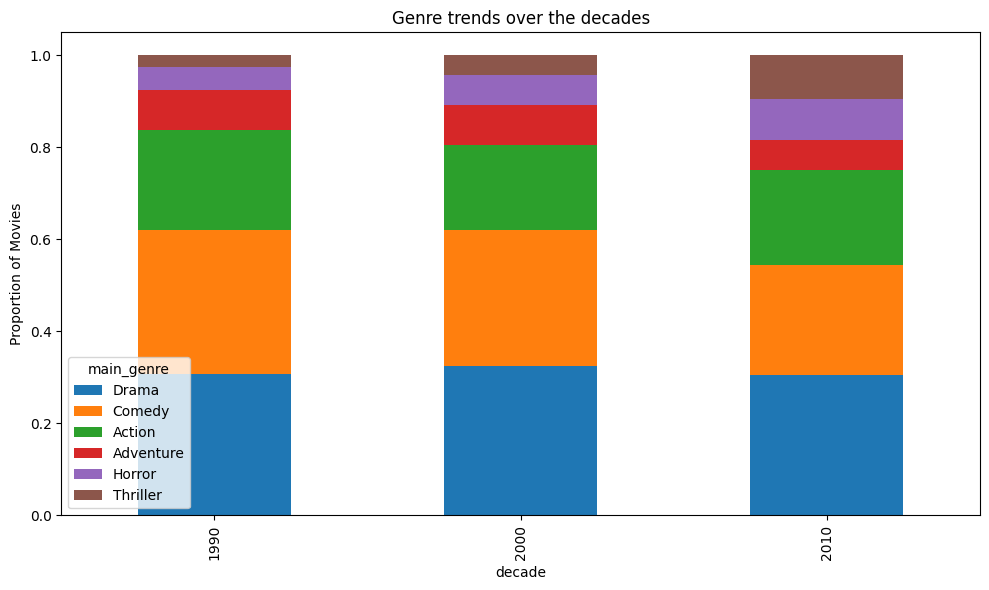

In [16]:
genre_pivot = genres_trends.pivot(
    index='decade',
    columns='main_genre',
    values='genre_count'
).fillna(0)

top_genres = genres_trends.groupby('main_genre')['genre_count'].sum().nlargest(6).index

genre_pivot = genre_pivot[top_genres]

genre_pivot_normalized = genre_pivot.div(genre_pivot.sum(axis=1), axis=0)

genre_pivot_normalized.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Genre trends over the decades")
plt.ylabel("Proportion of Movies")
plt.tight_layout()
plt.show()

The normalized visualization reveals how genre preferences have evolved over time. 

We can see Drama, Comedy and Action movies make up the largest portion of films in recent decades, maintaining a relatively stable share throughout.

Genres like Thriller and Horror became more dominant over time, as the amount of movies made in these genres grew every decade, while Adventure movies have seen a small decline in recent years.

### 2. Do higher-budget films tend to be more popular?

The data is grouped by both decade and budget category to analyze how the relationship between budget and popularity changes over time.

This allows us to compare whether high-budget films consistently dominate in popularity across different decades.

In [17]:
query2 = """
SELECT decade, 
AVG(popularity) AS avg_popularity, 
budget_category,
COUNT(*) as movie_count
FROM movies
WHERE decade IN (1990, 2000, 2010) AND budget_category != 'Unknown'
GROUP BY decade, budget_category
ORDER BY decade, avg_popularity DESC;
"""

budget_decade = pd.read_sql_query(query2, conn)

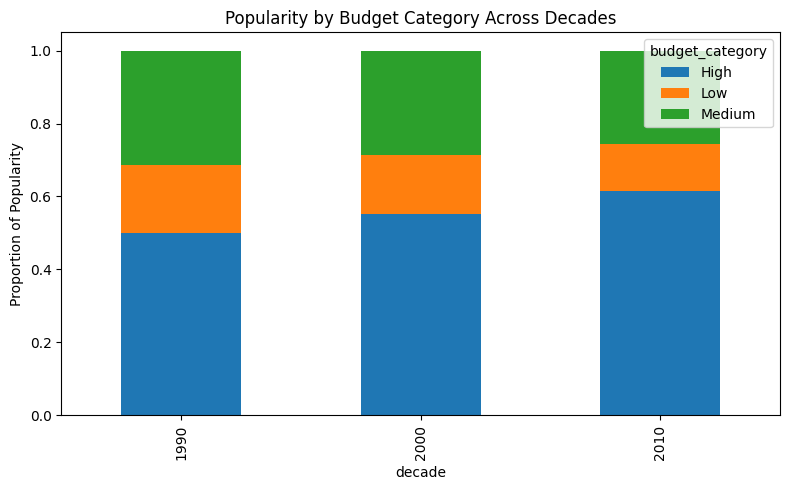

In [18]:
pivot_budget = budget_decade.pivot(
    index='decade',
    columns='budget_category',
    values='avg_popularity'
)

pivot_budget_normalized = pivot_budget.div(pivot_budget.sum(axis=1), axis=0)

pivot_budget_normalized.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Popularity by Budget Category Across Decades")
plt.ylabel("Proportion of Popularity")
plt.tight_layout()
plt.show()

High-budget films show increasing average popularity over time, becoming the most dominant category by the 2010s.


### 3. Language Trends 

The data is grouped by decade and original language to examine how language distribution in movies has changed over time.

This helps identify dominant languages as well as trends in the diversity of film production.

In [19]:
query3 = """
SELECT decade,
       original_language,
       COUNT(*) as movie_count
FROM movies
WHERE decade IN (1990, 2000, 2010)
GROUP BY decade, original_language
ORDER BY decade, movie_count DESC;
"""
language_decade = pd.read_sql_query(query3, conn)

In [20]:
top_languages = (
    language_decade.groupby('original_language')['movie_count']
    .sum()
    .nlargest(5)
    .index
)

language_decade = language_decade[
    language_decade['original_language'].isin(top_languages)
]

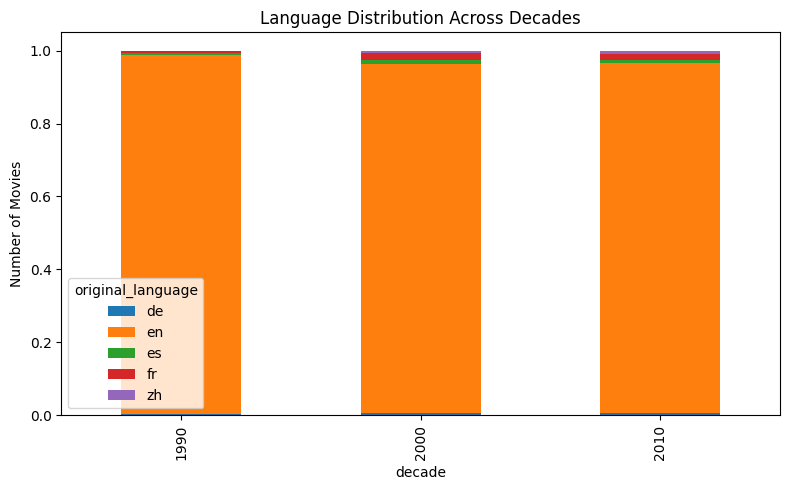

In [21]:
pivot_lang = language_decade.pivot(
    index='decade',
    columns='original_language',
    values='movie_count'
).fillna(0)

pivot_lang_normalized = pivot_lang.div(pivot_lang.sum(axis=1), axis=0)

pivot_lang_normalized.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Language Distribution Across Decades")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

English-language films dominate across all decades, but other languages show gradual growth, indicating increasing diversity in global film production.

# 6. Key Insights

- Genre distribution remains relatively stable, with Drama, Comedy, and Action consistently dominating, while Thriller and Horror have grown in share.
- High-budget films achieve higher average popularity and have become increasingly dominant over time.
- English-language films dominate the dataset, though other languages show gradual growth, suggesting increasing diversity in film production.